In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, Dense, MaxPool2D, Flatten, Dropout, Rescaling, RandomZoom, RandomRotation, RandomFlip
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import plot_model, image_dataset_from_directory

from sklearn.utils.class_weight import compute_class_weight

In [2]:
image_generator = ImageDataGenerator(
    rescale=1./255.,
    shear_range=0.1,
    zoom_range=0.3
)

image_generator_test = ImageDataGenerator(
    rescale=1./255.
)

In [3]:
train_data = image_dataset_from_directory(
    'data\data',
    image_size=(500, 500),
    color_mode='grayscale',
    batch_size=32,
    label_mode='binary',
    shuffle=True
)

Found 550 files belonging to 2 classes.


In [4]:
test_data = image_dataset_from_directory(
    r'data\test_data',
    image_size=(500, 500),
    color_mode='grayscale',
    batch_size=32,
    label_mode='binary',
    shuffle=False

)

Found 74 files belonging to 2 classes.


In [5]:
data_augmentation = Sequential([
    RandomFlip('horizontal'),
    RandomRotation(0.1),
    RandomZoom(0.3)
])

In [6]:
data_normalization = Rescaling(1./255.)

In [8]:
model = Sequential([
    Input(shape=(500, 500, 1)),

    data_normalization,

    data_augmentation,

    Conv2D(32, (3, 3), activation='relu'),

    MaxPool2D(pool_size=(2, 2)),

    Dropout(0.2),

    Conv2D(32, (3, 3), activation='relu'),

    MaxPool2D(pool_size=(2, 2)),

    Dropout(0.2),

    Conv2D(64, (3, 3), activation='relu'),

    MaxPool2D(pool_size=(2, 2)),

    Dropout(0.2),

    Conv2D(64, (3, 3), activation='relu'),

    MaxPool2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(64, activation='relu'),

    Dense(1, activation='sigmoid'),

])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 500, 500, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 500, 500, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 498, 498, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 249, 249, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 249, 249, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 247, 247, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 123, 123, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 123, 123, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 121, 121, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 60, 60, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 60, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 58, 58, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 53824)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,889,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,962,913 (26.56 MB)

 Trainable params: 6,962,913 (26.56 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy'])

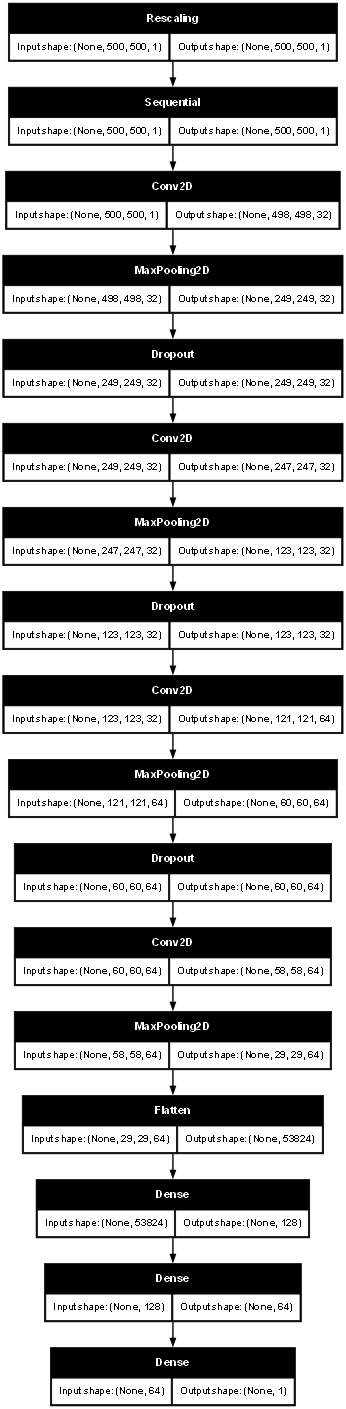

In [10]:
plot_model(model, show_shapes=True, show_layer_names=False, dpi=50)

In [11]:
all_labels = np.concatenate(
    [y.numpy().astype(int).flatten() for _, y in train_data])
classes = np.unique(all_labels)

weights = compute_class_weight(
    class_weight='balanced', classes=classes, y=all_labels)

In [12]:
class_weights = dict(zip(classes, weights))
class_weights

{np.int64(0): np.float64(1.3959390862944163),
 np.int64(1): np.float64(0.7790368271954674)}

In [13]:
es = EarlyStopping(monitor='val_loss', mode='min', patience=5,
                   verbose=1, restore_best_weights=True)
rlrop = ReduceLROnPlateau(monitor='val_loss', mode='min',
                          patience=3, factor=0.5, verbose=1, min_lr=1e-6)

In [14]:
mch = ModelCheckpoint(filepath='bestCNNXray.keras', monitor='val_loss',
                      mode='min', verbose=1, save_best_only=True, )

In [15]:
for x_val, y_val in test_data.take(1):
    print("Shape of x_val:", x_val.shape)
    print("Shape of y_val:", y_val.shape)

print(test_data.element_spec)

Shape of x_val: (32, 500, 500, 1)
Shape of y_val: (32, 1)
(TensorSpec(shape=(None, 500, 500, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))


In [16]:
history = model.fit(
    train_data,
    epochs=30,
    steps_per_epoch=len(train_data),
    validation_data=test_data,
    validation_steps=len(test_data),
    class_weight=class_weights,
    callbacks=[es, rlrop, mch]
)

Epoch 1/30


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4794 - loss: 0.7375
Epoch 1: val_loss improved from None to 0.69236, saving model to bestCNNXray.keras

Epoch 1: finished saving model to bestCNNXray.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.4182 - loss: 0.7101 - val_accuracy: 0.5000 - val_loss: 0.6924 - learning_rate: 0.0010
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4541 - loss: 0.6745
Epoch 2: val_loss improved from 0.69236 to 0.66495, saving model to bestCNNXray.keras

Epoch 2: finished saving model to bestCNNXray.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.5145 - loss: 0.6782 - val_accuracy: 0.7027 - val_loss: 0.6649 - learning_rate: 0.0010
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7093 - loss: 0.6212
Epoch 3: val_loss did not improve from 0.66495
18/18 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.7055 - loss: 0.6109 - val_accuracy: 0.5270 - val_loss: 0.6737 - learning_rate: 0.0010
Epoch 4/30
18/18 ━━━━━━

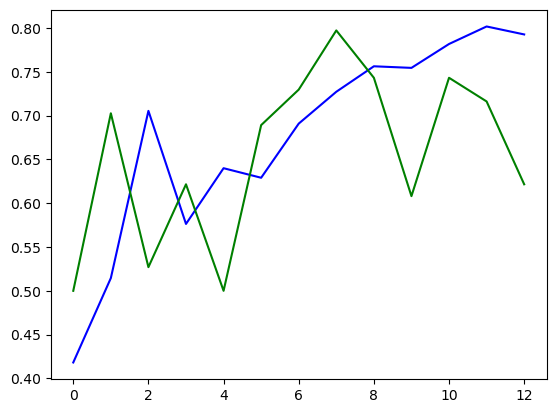

In [17]:
plt.plot(history.history['accuracy'], color='blue')
plt.plot(history.history['val_accuracy'], color='green')

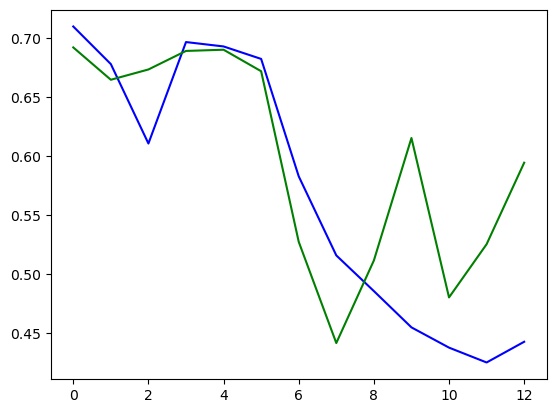

In [18]:
plt.plot(history.history['loss'], color='blue')
plt.plot(history.history['val_loss'], color='green')